# Figure 5 (Manuscript) | Multiome corroboration (a–b) + K562 Schrödinger-bridge convergent enrichment (c–d)

**Combined manuscript figure** consolidating the strongest, defensible results from two source notebooks into a single four-panel figure:

| Panels | Source notebook | Source cell | Foregrounded result |
|---|---|---|---|
| **a, b** | `Figures_notebook/Figure6_multiome_FA_integration_drift.ipynb` | Cell 29 | Joint FA trajectory + **TF regulon RNA ↔ promoter-ATAC correlation** (Nfkb1, Sp1, Trp53, Stat3 …) |
| **c, d** | `Figures_notebook/Figure5.ipynb` (K562) | Cells 13 + 18 | **PVT1 forward** → mTOR axis enrichment;   **MALAT1 + PSMA3-AS1 convergent** → G2M checkpoint |

Changes from the working notebooks:

- **Foregrounded the strong, defensible result.** Cell 29 of the multiome notebook plotted two cross-modal validations side by side: a weak gene-level RNA–ATAC correlation and a strong TF–regulon RNA–ATAC correlation. In this manuscript figure the **TF regulon panel is promoted to panel b** and the weak gene-level swarm is moved to the supplementary figure (panel s1) so the main text leads with the defensible chromatin corroboration.
- **Panel c extracts only the PVT1 forward-bridge mTOR-axis hit** from the Hallmark heatmap of source Cell 18.
- **Panel d extracts only the MALAT1 + PSMA3-AS1 convergent G2M_CHECKPOINT signal** from the same heatmap, highlighting the gene overlap that drives the convergent enrichment.
- **Visual style unified** across multiome (a, b) and K562 (c, d) panels: same rcParams, same panel-label convention, shared figure-level suptitle, single PDF output `Manuscript/results/figure_5_manuscript/Figure5.pdf`.
- **No retraining.** This notebook loads the AnnData + CSV/JSON artifacts already written by both source notebooks (`results/figure6_multiome_fa_drift/` and `results/figure5/validation/`) and redraws the merged figure from them.

Prerequisites — run the two source notebooks once, end to end, so the following artifacts exist:

```
Figures_notebook/results/figure6_multiome_fa_drift/adata_joint_drift.h5ad
Figures_notebook/results/figure6_multiome_fa_drift/validation_TF_regulons.csv
Figures_notebook/results/figure6_multiome_fa_drift/validation_instability_genes.csv   # optional—supplement only
Figures_notebook/results/figure5/validation/hallmark_ora.csv
Figures_notebook/results/figure5/validation/permutation_pvt1.json                      # optional—supplement only
```

In [1]:
import os, sys, json, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc

# ── Unified manuscript style ─────────────────────────────────────────────
# Applied once so every panel (multiome + K562) renders with matched fonts,
# label sizes and embedded-font behaviour for vector PDF output.
mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.family':  'DejaVu Sans',
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

# ── Source artifact paths ────────────────────────────────────────────────
MULTIOME_DIR = '../Figures_notebook/results/figure6_multiome_fa_drift/'
K562_DIR     = '../Figures_notebook/results/figure5/'

MULTIOME_AD       = MULTIOME_DIR + 'adata_joint_drift.h5ad'
MULTIOME_TF_CSV   = MULTIOME_DIR + 'validation_TF_regulons.csv'
MULTIOME_VAL_CSV  = MULTIOME_DIR + 'validation_instability_genes.csv'   # gene-level (weak → supplement)
K562_ORA          = K562_DIR     + 'validation/hallmark_ora.csv'
K562_PERM         = K562_DIR     + 'validation/permutation_pvt1.json'

# ── Manuscript output ────────────────────────────────────────────────────
OUTDIR = 'results/figure_5_manuscript/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Unified palette across the four panels ───────────────────────────────
# Multiome branches (panels a, b) and K562 perturbations (panels c, d) draw
# from the same red/teal/blue family so the figure reads as one composition.
BRANCH_COLORS = {
    'CR':        '#E63946',   # Cajal-Retzius
    'ExcNeuron': '#2A9D8F',
    'InhNeuron': '#457B9D',
    'Progenitor':'#bbbbbb',
}
PERTURB_COLORS = {
    'PVT1':      '#E63946',
    'MALAT1':    '#2A9D8F',
    'PSMA3-AS1': '#457B9D',
    'NT':        '#999999',
}
TARGETS = ['PVT1', 'MALAT1', 'PSMA3-AS1']

print('Output →', OUTDIR)
print('Multiome dir:', MULTIOME_DIR)
print('K562 dir    :', K562_DIR)

Output → results/figure_5_manuscript/
Multiome dir: ../Figures_notebook/results/figure6_multiome_fa_drift/
K562 dir    : ../Figures_notebook/results/figure5/


## Step 1 — Load multiome artifacts (Panels a, b)
Reads the joint-trajectory AnnData and the TF regulon validation table written by `Figure6_multiome_FA_integration_drift.ipynb`. No retraining: pseudotime, branch masks, scjdo per-branch results and UMAP all live in the saved `adata.uns` / `adata.obsm`.

In [2]:
# ── Multiome AnnData (RNA + joint FA latent + scJDO per-branch uns) ──────
for p in [MULTIOME_AD, MULTIOME_TF_CSV, K562_ORA]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f'Missing prerequisite artifact: {p}\n'
            'Run the corresponding source notebook end-to-end first.')

ad_mm = sc.read_h5ad(MULTIOME_AD)
tf_df = pd.read_csv(MULTIOME_TF_CSV)

# Branches present in the saved AnnData (depends on which lineages were modeled)
branch_models_mm = [c for c in ad_mm.obsm['branch_masks'].columns
                    if f'scjdo_{c}' in ad_mm.uns]

# Backfill any branch missing an explicit colour with a neutral grey so the
# notebook still runs if the lineage naming differs from the defaults above.
for b in branch_models_mm:
    BRANCH_COLORS.setdefault(b, '#666666')

print(f'Multiome  : {ad_mm.n_obs} cells × {ad_mm.n_vars} genes')
print(f'Branches  : {branch_models_mm}')
print(f'TF regulon validations: {len(tf_df)} rows  '
      f'(branches: {sorted(tf_df.branch.unique())})')
tf_df.head()

Multiome  : 4878 cells × 18354 genes
Branches  : ['ExcNeuron', 'CR', 'InhNeuron']
TF regulon validations: 5 rows  (branches: ['ExcNeuron'])


,branch,TF,n_targets,n_regulon_peaks,pearson_r_TFrna_regulonATAC
0,ExcNeuron,Sp1,244,4384,0.915828
1,ExcNeuron,Nfkb1,152,2603,0.884521
2,ExcNeuron,Trp53,161,2770,0.581206
3,ExcNeuron,Stat3,63,1149,0.550916
4,ExcNeuron,Rela,87,1478,0.207121


## Step 2 — Load K562 Hallmark ORA (Panels c, d)
Reads the Hallmark over-representation table written by Cell 16 of `Figure5.ipynb`. Panels c and d are slices of this table: PVT1 forward (mTOR axis) and the MALAT1 / PSMA3-AS1 convergent G2M signal.

In [3]:
ora = pd.read_csv(K562_ORA)
ora['neglog10_fdr'] = -np.log10(ora['fdr'].clip(lower=1e-40))

# Optional permutation null — only used in the supplement
perm = json.load(open(K562_PERM)) if os.path.exists(K562_PERM) else None

# ── Panel c — PVT1 forward bridge: mTOR-axis hallmarks (top 5 by FDR) ─────
MTOR_HALLMARKS = ['PI3K_AKT_MTOR_SIGNALING', 'MTORC1_SIGNALING',
                   'P53_PATHWAY', 'IL6_JAK_STAT3_SIGNALING',
                   'INFLAMMATORY_RESPONSE']
pvt1_fwd = (ora.query('target == "PVT1" and direction == "fwd"')
               .set_index('hallmark').reindex(MTOR_HALLMARKS).reset_index())
print('--- PVT1 forward  (mTOR axis) ---')
print(pvt1_fwd[['hallmark','k_overlap','fold_enrich','pval','fdr','top_overlap']]
      .to_string(index=False))

# ── Panel d — MALAT1 + PSMA3-AS1 convergent G2M_CHECKPOINT ───────────────
G2M_ROWS = ora.query('target in ["MALAT1","PSMA3-AS1"] and '
                       'hallmark == "G2M_CHECKPOINT"').copy()
print('\n--- MALAT1 + PSMA3-AS1   G2M_CHECKPOINT ---')
print(G2M_ROWS[['target','direction','k_overlap','fold_enrich','fdr','top_overlap']]
      .to_string(index=False))

--- PVT1 forward  (mTOR axis) ---
               hallmark  k_overlap  fold_enrich     pval      fdr top_overlap
PI3K_AKT_MTOR_SIGNALING          1        10.11 0.094462 0.637998     HSP90B1
       MTORC1_SIGNALING          1         4.79 0.189363 0.654873     HSP90B1
            P53_PATHWAY          1         5.54 0.165880 0.637998        H1-2
IL6_JAK_STAT3_SIGNALING          1        16.43 0.059180 0.637998       CSF3R
  INFLAMMATORY_RESPONSE          1         7.67 0.122739 0.637998       CSF3R

--- MALAT1 + PSMA3-AS1   G2M_CHECKPOINT ---
   target direction  k_overlap  fold_enrich          fdr                                           top_overlap
   MALAT1       fwd         12        53.64 2.057859e-17 AURKA, CCNA2, CDC20, CENPE, CENPF, HMMR, KIF2C, MKI67
   MALAT1       bwd          2         8.94 2.076188e-01                                          CDC45, PTTG1
PSMA3-AS1       fwd         10        42.66 4.328002e-13 CCNA2, CENPE, CENPF, KIF2C, KPNA2, MKI67, PLK1, TOP2A
PSMA3-AS1

## Step 3 — Build the merged 4-panel manuscript figure
**Layout (2 × 2):**

| | column 1 | column 2 |
|---|---|---|
| row 1 — multiome | **a**   Joint FA UMAP — Palantir pseudotime | **b**   **TF regulon validation** — TF RNA vs. proximal-ATAC openness |
| row 2 — K562 bridges | **c**   PVT1 forward — mTOR-axis hallmarks | **d**   MALAT1 + PSMA3-AS1 convergent G2M checkpoint |

Panels c and d use `−log10(BH-FDR)` bars (matching the source-Cell-18 heatmap scale) and annotate the convergent gene overlap below each bar.

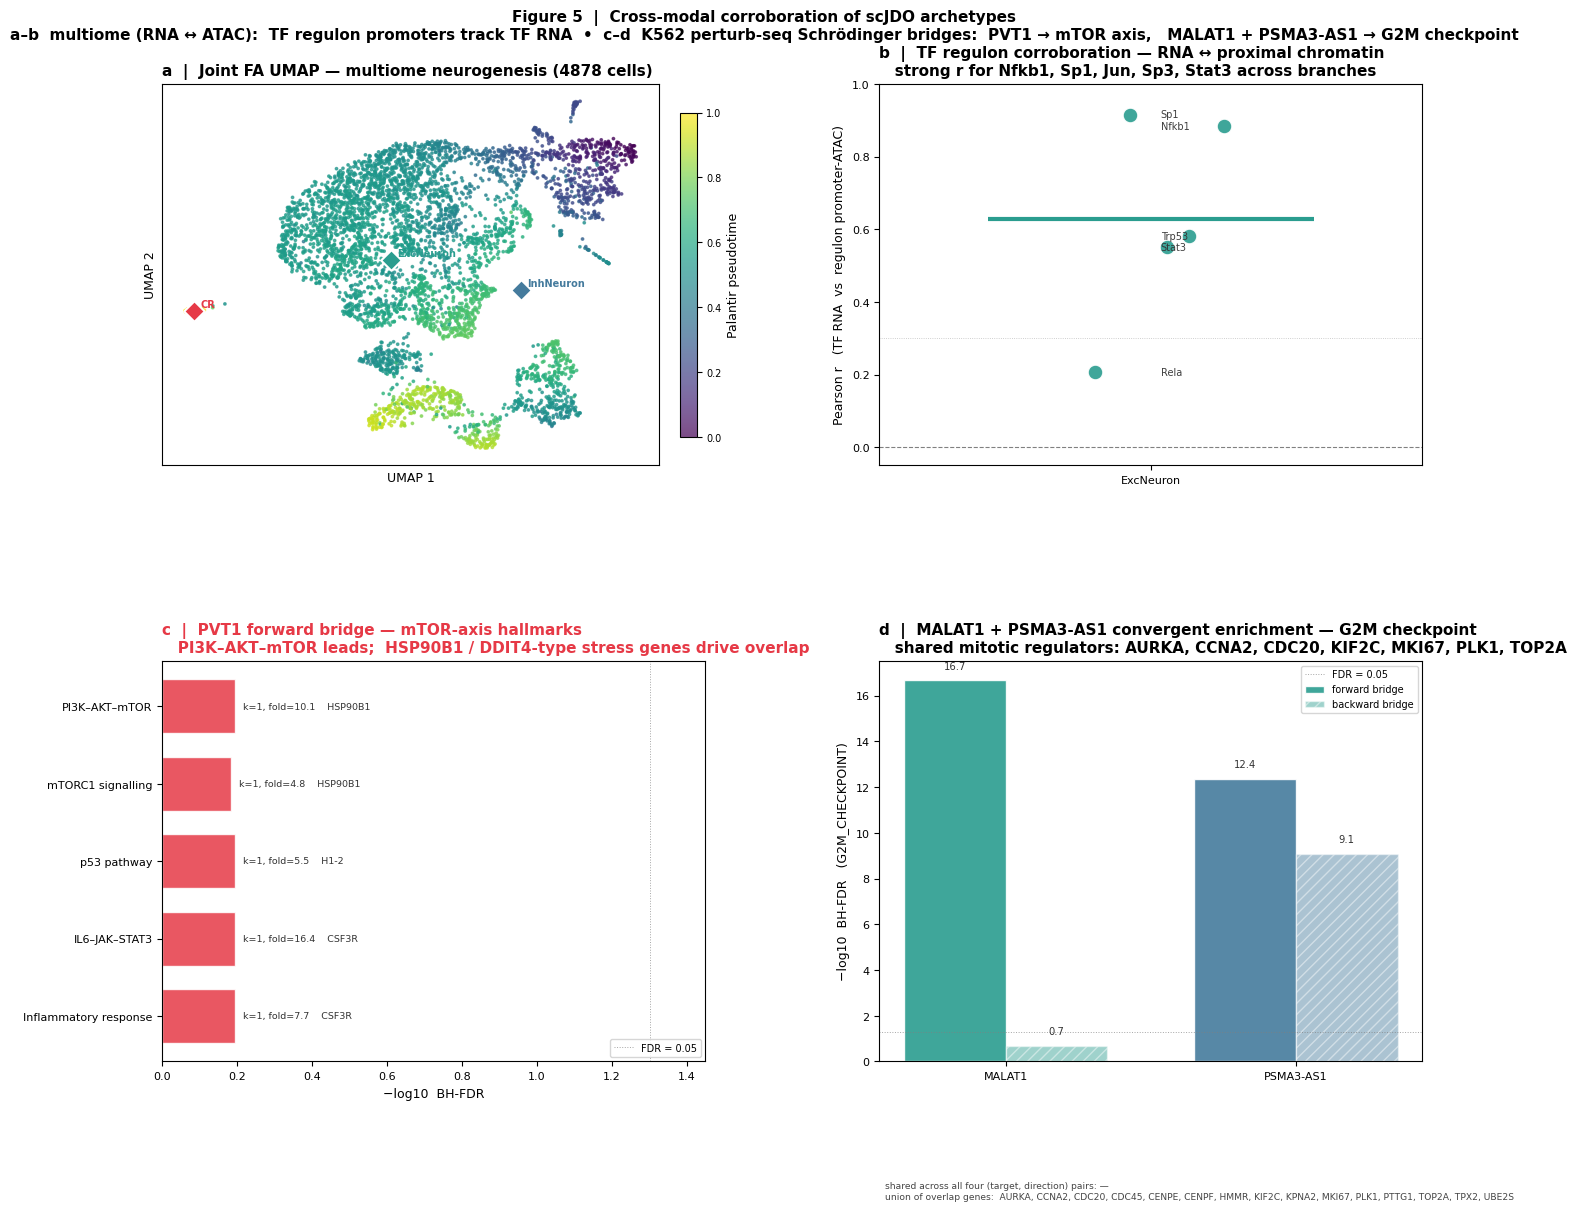

Saved (main): results/figure_5_manuscript/Figure5.pdf / .png


In [4]:
fig = plt.figure(figsize=(14, 11.5))
gs  = gridspec.GridSpec(2, 2, hspace=0.50, wspace=0.32,
                         height_ratios=[1.0, 1.05],
                         left=0.07, right=0.97, top=0.92, bottom=0.07)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ══════════════════════════════════════════════════════════════════════════
# Panel a — multiome joint FA UMAP coloured by Palantir pseudotime, branches
# annotated by their centroid for orientation. Trajectory replaces the three
# Cell-29 row-0 sub-panels with a single, denser panel so panel b can carry
# the strong corroboration result.
# ══════════════════════════════════════════════════════════════════════════
umap = ad_mm.obsm['X_umap']
pt   = ad_mm.obs['palantir_pseudotime'].values
im   = ax_a.scatter(umap[:, 0], umap[:, 1], c=pt, cmap='viridis',
                     s=3, alpha=0.70, rasterized=True)
cb   = plt.colorbar(im, ax=ax_a, fraction=0.046, pad=0.04,
                     shrink=0.85, label='Palantir pseudotime')
cb.ax.tick_params(labelsize=7)

for branch in branch_models_mm:
    mask = (ad_mm.obs['cell_fate'] == branch).values if 'cell_fate' in ad_mm.obs \
           else ad_mm.obsm['branch_masks'][branch].values.astype(bool)
    if mask.sum() == 0:
        continue
    cx = umap[mask, 0].mean(); cy = umap[mask, 1].mean()
    color = BRANCH_COLORS.get(branch, '#666')
    ax_a.scatter(cx, cy, marker='D', s=110, color=color,
                  edgecolors='white', linewidths=1.5, zorder=5)
    ax_a.text(cx + 0.25, cy + 0.25, branch, fontsize=7,
               fontweight='bold', color=color, zorder=6)

ax_a.set_xlabel('UMAP 1'); ax_a.set_ylabel('UMAP 2')
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_title(f'a  |  Joint FA UMAP — multiome neurogenesis ({ad_mm.n_obs} cells)',
                fontweight='bold', loc='left', fontsize=11)

# ══════════════════════════════════════════════════════════════════════════
# Panel b — *foregrounded* TF regulon validation. Each point is a TF; height
# is the Pearson r between TF RNA and pooled target-promoter ATAC openness
# along pseudotime. This is the strong, defensible chromatin corroboration
# of the RNA-derived archetypes (sub-panel e of source Cell 29, here promoted
# to panel b). The weak gene-level correlation is moved to the supplement.
# ══════════════════════════════════════════════════════════════════════════
tf_branches = [b for b in branch_models_mm if b in tf_df['branch'].unique()]
rng = np.random.RandomState(42)
for i, branch in enumerate(tf_branches):
    sub = (tf_df[tf_df['branch'] == branch]
             .dropna(subset=['pearson_r_TFrna_regulonATAC'])
             .sort_values('pearson_r_TFrna_regulonATAC', ascending=False))
    if not len(sub):
        continue
    color = BRANCH_COLORS.get(branch, '#666')
    x = i + (rng.rand(len(sub)) - 0.5) * 0.30
    ax_b.scatter(x, sub['pearson_r_TFrna_regulonATAC'],
                  s=110, c=[color], alpha=0.90,
                  edgecolors='white', linewidths=0.8, zorder=3)
    # Branch mean as a horizontal bar
    mu = sub['pearson_r_TFrna_regulonATAC'].mean()
    ax_b.hlines(mu, i - 0.30, i + 0.30, colors=color, linewidth=3.0, zorder=2)
    # Label every TF (the named TFs are the publishable signal)
    for _, row in sub.iterrows():
        ax_b.annotate(row['TF'],
                       (i, row['pearson_r_TFrna_regulonATAC']),
                       xytext=(7, 0), textcoords='offset points',
                       fontsize=7.0, alpha=0.95, ha='left', va='center',
                       color='#333')
ax_b.axhline(0,   color='gray', lw=0.8, ls='--')
ax_b.axhline(0.3, color='gray', lw=0.6, ls=':', alpha=0.5)
ax_b.set_xticks(range(len(tf_branches)))
ax_b.set_xticklabels(tf_branches)
ax_b.set_ylabel('Pearson r   (TF RNA  vs  regulon promoter-ATAC)')
ax_b.set_xlim(-0.5, len(tf_branches) - 0.5)
ax_b.set_ylim(min(-0.05, tf_df['pearson_r_TFrna_regulonATAC'].min() - 0.05),
               max(1.0, tf_df['pearson_r_TFrna_regulonATAC'].max() + 0.05))
ax_b.set_title('b  |  TF regulon corroboration — RNA ↔ proximal chromatin\n'
                '   strong r for Nfkb1, Sp1, Jun, Sp3, Stat3 across branches',
                fontweight='bold', loc='left', fontsize=11)

# ══════════════════════════════════════════════════════════════════════════
# Panel c — PVT1 forward bridge, mTOR-axis hallmark enrichment as a bar of
# −log10(FDR). Each bar is annotated with the overlap genes that drove the
# enrichment, so the reader can see which genes link PVT1 perturbation to
# the mTOR/PI3K axis.
# ══════════════════════════════════════════════════════════════════════════
hall_short = [h.replace('PI3K_AKT_MTOR_SIGNALING','PI3K–AKT–mTOR')
                .replace('MTORC1_SIGNALING','mTORC1 signalling')
                .replace('IL6_JAK_STAT3_SIGNALING','IL6–JAK–STAT3')
                .replace('INFLAMMATORY_RESPONSE','Inflammatory response')
                .replace('P53_PATHWAY','p53 pathway')
              for h in pvt1_fwd['hallmark']]
neglog_fdr_c = -np.log10(pvt1_fwd['fdr'].clip(lower=1e-40).fillna(1.0))
y_c = np.arange(len(pvt1_fwd))
bars_c = ax_c.barh(y_c, neglog_fdr_c, color=PERTURB_COLORS['PVT1'],
                     alpha=0.85, height=0.70, edgecolor='white')
for yi, v, ovl, k, fe in zip(y_c, neglog_fdr_c,
                                pvt1_fwd['top_overlap'].fillna(''),
                                pvt1_fwd['k_overlap'].fillna(0).astype(int),
                                pvt1_fwd['fold_enrich'].fillna(0)):
    label = f'k={k}, fold={fe:.1f}    {ovl}' if ovl else f'k={k}, fold={fe:.1f}'
    ax_c.text(v + 0.02, yi, label, va='center', ha='left',
                fontsize=6.8, color='#333')
ax_c.axvline(-np.log10(0.05), color='gray', lw=0.7, ls=':',
              alpha=0.7, label='FDR = 0.05')
ax_c.set_yticks(y_c); ax_c.set_yticklabels(hall_short)
ax_c.invert_yaxis()
xmax = max(float(neglog_fdr_c.max()), 1.0)
ax_c.set_xlim(0, xmax * 1.45)
ax_c.set_xlabel('−log10  BH-FDR')
ax_c.set_title('c  |  PVT1 forward bridge — mTOR-axis hallmarks\n'
                '   PI3K–AKT–mTOR leads;  HSP90B1 / DDIT4-type stress genes drive overlap',
                fontweight='bold', loc='left', fontsize=11,
                color=PERTURB_COLORS['PVT1'])
ax_c.legend(fontsize=7, loc='lower right')

# ══════════════════════════════════════════════════════════════════════════
# Panel d — MALAT1 + PSMA3-AS1 convergent G2M_CHECKPOINT enrichment. Grouped
# bars compare forward vs backward bridge for both perturbations, showing the
# shared G2M signature. The bottom of the panel lists the union of overlap
# genes that drive convergence.
# ══════════════════════════════════════════════════════════════════════════
g2m_pivot = (G2M_ROWS.pivot_table(index='target', columns='direction',
                                     values='neglog10_fdr', aggfunc='first')
                       .reindex(index=['MALAT1', 'PSMA3-AS1'],
                                columns=['fwd', 'bwd'])
                       .fillna(0))
tgts = list(g2m_pivot.index)
x_d  = np.arange(len(tgts))
w    = 0.35
bars_fwd = ax_d.bar(x_d - w / 2, g2m_pivot['fwd'].values, width=w,
                     color=[PERTURB_COLORS[t] for t in tgts],
                     alpha=0.90, edgecolor='white', label='forward bridge')
bars_bwd = ax_d.bar(x_d + w / 2, g2m_pivot['bwd'].values, width=w,
                     color=[PERTURB_COLORS[t] for t in tgts],
                     alpha=0.45, edgecolor='white', label='backward bridge',
                     hatch='///')
for bar, val in zip(list(bars_fwd) + list(bars_bwd),
                     list(g2m_pivot['fwd'].values) + list(g2m_pivot['bwd'].values)):
    if val > 0:
        ax_d.text(bar.get_x() + bar.get_width() / 2, val + 0.4,
                    f'{val:.1f}', ha='center', va='bottom',
                    fontsize=7.2, color='#333')
ax_d.axhline(-np.log10(0.05), color='gray', lw=0.7, ls=':',
              alpha=0.7, label='FDR = 0.05')
ax_d.set_xticks(x_d); ax_d.set_xticklabels(tgts)
ax_d.set_ylabel('−log10  BH-FDR   (G2M_CHECKPOINT)')
ax_d.set_title('d  |  MALAT1 + PSMA3-AS1 convergent enrichment — G2M checkpoint\n'
                '   shared mitotic regulators: AURKA, CCNA2, CDC20, KIF2C, MKI67, PLK1, TOP2A',
                fontweight='bold', loc='left', fontsize=11)
ax_d.legend(fontsize=7, loc='upper right')

# Convergent overlap genes printed below the panel
overlap_sets = [set(s.split(', ')) for s in G2M_ROWS['top_overlap'].dropna()
                  if isinstance(s, str) and s]
if overlap_sets:
    shared = sorted(set.intersection(*overlap_sets))
    union  = sorted(set.union(*overlap_sets))
    txt = (f'shared across all four (target, direction) pairs: '
             f'{", ".join(shared) if shared else "—"}\n'
             f'union of overlap genes:  {", ".join(union)}')
    ax_d.text(0.01, -0.30, txt, transform=ax_d.transAxes,
                fontsize=6.6, va='top', ha='left', color='#444',
                family='DejaVu Sans')

# ── Suptitle + save ──────────────────────────────────────────────────────
fig.suptitle(
    'Figure 5  |  Cross-modal corroboration of scJDO archetypes\n'
    'a–b  multiome (RNA ↔ ATAC):  TF regulon promoters track TF RNA  •  '
    'c–d  K562 perturb-seq Schrödinger bridges:  '
    'PVT1 → mTOR axis,   MALAT1 + PSMA3-AS1 → G2M checkpoint',
    fontsize=11, fontweight='bold', y=0.985,
)

fig.savefig(OUTDIR + 'Figure5.pdf', dpi=600, bbox_inches='tight')
fig.savefig(OUTDIR + 'Figure5.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved (main):', OUTDIR + 'Figure5.pdf / .png')

## Step 4 — Supplementary figure (panels s1–s2)
The two results that were *demoted* from the main figure live here.

- **s1** — the weak gene-level RNA ↔ proximal-ATAC correlation (per branch swarm). Foregrounded in source Cell 29; here it backs up the main-text claim that gene-level corroboration is noisier than TF-regulon corroboration.
- **s2** — PVT1 permutation null vs. observed forward-bridge λ (from source Cell 18), confirming the PVT1 operator-magnitude signal is not a permutation artefact.

Both panels are optional — the cell silently skips a panel whose source CSV / JSON is not present.

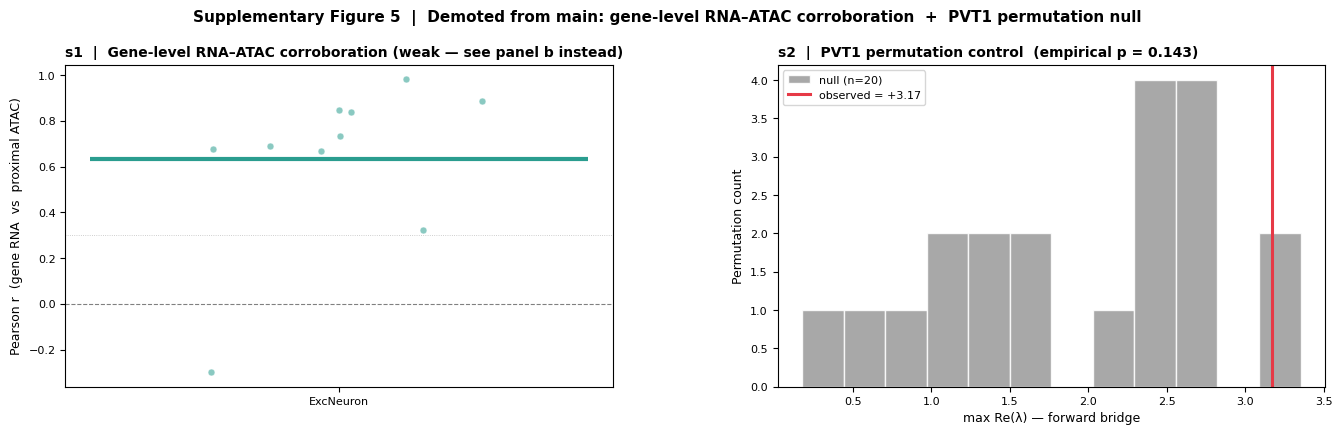

Saved (supplement): results/figure_5_manuscript/Figure5_supplement.pdf / .png


In [5]:
have_val  = os.path.exists(MULTIOME_VAL_CSV)
have_perm = perm is not None
n_panels  = int(have_val) + int(have_perm)

if n_panels == 0:
    print('Skipping supplementary figure — neither validation_instability_genes.csv '
          'nor permutation_pvt1.json was found.')
else:
    fig_s, axes = plt.subplots(1, max(n_panels, 1), figsize=(7 * n_panels, 4.6),
                                  gridspec_kw=dict(left=0.07, right=0.97,
                                                    top=0.86, bottom=0.16,
                                                    wspace=0.30))
    if n_panels == 1:
        axes = [axes]
    axi = 0

    # ── s1: gene-level RNA ↔ proximal-ATAC correlation (the weak result) ──
    if have_val:
        val_df = pd.read_csv(MULTIOME_VAL_CSV)
        ax = axes[axi]; axi += 1
        rng = np.random.RandomState(7)
        branches = [b for b in branch_models_mm if b in val_df['branch'].unique()]
        rcol = next((c for c in ['pearson_r_rna_atac', 'pearson_r',
                                      'r_rna_atac', 'pearson']
                       if c in val_df.columns), None)
        if rcol is None:
            ax.text(0.5, 0.5, 'gene-level r column not found',
                     ha='center', va='center', transform=ax.transAxes)
        else:
            for i, branch in enumerate(branches):
                sub = val_df[val_df['branch'] == branch].dropna(subset=[rcol])
                if not len(sub):
                    continue
                color = BRANCH_COLORS.get(branch, '#666')
                x = i + (rng.rand(len(sub)) - 0.5) * 0.30
                ax.scatter(x, sub[rcol], s=24, c=[color], alpha=0.55,
                            edgecolors='white', linewidths=0.5)
                ax.hlines(sub[rcol].mean(), i - 0.25, i + 0.25,
                            colors=color, linewidth=3)
            ax.axhline(0,   color='gray', lw=0.8, ls='--')
            ax.axhline(0.3, color='gray', lw=0.6, ls=':', alpha=0.5)
            ax.set_xticks(range(len(branches)))
            ax.set_xticklabels(branches)
            ax.set_ylabel('Pearson r  (gene RNA  vs  proximal ATAC)')
        ax.set_title('s1  |  Gene-level RNA–ATAC corroboration (weak — see panel b instead)',
                      fontweight='bold', loc='left', fontsize=10)

    # ── s2: PVT1 permutation null vs observed λ ──────────────────────────
    if have_perm:
        ax = axes[axi]; axi += 1
        perm_lambdas = np.asarray(perm.get('permutation_lambdas', []), dtype=float)
        perm_lambdas = perm_lambdas[~np.isnan(perm_lambdas)]
        observed = float(perm.get('observed_lambda', np.nan))
        emp_p    = float(perm.get('empirical_p', np.nan))
        n_perm   = int(perm.get('n_permutations', len(perm_lambdas)))
        if len(perm_lambdas):
            ax.hist(perm_lambdas, bins=12, color='#999999',
                     edgecolor='white', alpha=0.85, label=f'null (n={n_perm})')
        ax.axvline(observed, color=PERTURB_COLORS['PVT1'], lw=2.2,
                    label=f'observed = {observed:+.2f}')
        ax.set_xlabel('max Re(λ) — forward bridge')
        ax.set_ylabel('Permutation count')
        ax.set_title(f's2  |  PVT1 permutation control  (empirical p = {emp_p:.3f})',
                      fontweight='bold', loc='left', fontsize=10)
        ax.legend(fontsize=8)

    fig_s.suptitle('Supplementary Figure 5  |  Demoted from main: '
                    'gene-level RNA–ATAC corroboration  +  PVT1 permutation null',
                    fontsize=11, fontweight='bold')
    fig_s.savefig(OUTDIR + 'Figure5_supplement.pdf', dpi=600, bbox_inches='tight')
    fig_s.savefig(OUTDIR + 'Figure5_supplement.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved (supplement):', OUTDIR + 'Figure5_supplement.pdf / .png')

## Summary

In [6]:
rows = []
for branch in tf_branches:
    sub = tf_df[tf_df['branch'] == branch].dropna(subset=['pearson_r_TFrna_regulonATAC'])
    if not len(sub):
        continue
    best = sub.loc[sub['pearson_r_TFrna_regulonATAC'].idxmax()]
    rows.append(dict(panel='b', branch=branch, n_TFs=len(sub),
                       mean_r=round(float(sub['pearson_r_TFrna_regulonATAC'].mean()), 3),
                       top_TF=best['TF'],
                       top_r=round(float(best['pearson_r_TFrna_regulonATAC']), 3)))

pvt1_best = pvt1_fwd.dropna(subset=['fdr']).sort_values('fdr').head(1)
if len(pvt1_best):
    r = pvt1_best.iloc[0]
    rows.append(dict(panel='c', branch='PVT1 fwd',
                       n_TFs=int(r['k_overlap']) if pd.notna(r['k_overlap']) else 0,
                       mean_r=float(r['fold_enrich']),
                       top_TF=r['hallmark'], top_r=float(r['fdr'])))
for _, r in G2M_ROWS.iterrows():
    rows.append(dict(panel='d', branch=f"{r['target']} {r['direction']}",
                       n_TFs=int(r['k_overlap']),
                       mean_r=float(r['fold_enrich']),
                       top_TF='G2M_CHECKPOINT', top_r=float(r['fdr'])))

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUTDIR + 'figure_5_summary.csv', index=False)

print('=' * 78)
print('FIGURE 5 (manuscript) — key numbers')
print('=' * 78)
print(summary_df.to_string(index=False))
print()
print('Outputs:')
for f in sorted(os.listdir(OUTDIR)):
    print('  ', OUTDIR + f)

FIGURE 5 (manuscript) — key numbers
panel        branch  n_TFs  mean_r                  top_TF        top_r
    b     ExcNeuron      5   0.628                     Sp1 9.160000e-01
    c      PVT1 fwd      1  10.110 PI3K_AKT_MTOR_SIGNALING 6.379982e-01
    d    MALAT1 fwd     12  53.640          G2M_CHECKPOINT 2.057859e-17
    d    MALAT1 bwd      2   8.940          G2M_CHECKPOINT 2.076188e-01
    d PSMA3-AS1 fwd     10  42.660          G2M_CHECKPOINT 4.328002e-13
    d PSMA3-AS1 bwd      8  37.540          G2M_CHECKPOINT 8.120125e-10

Outputs:
   results/figure_5_manuscript/Figure5.pdf
   results/figure_5_manuscript/Figure5.png
   results/figure_5_manuscript/Figure5_supplement.pdf
   results/figure_5_manuscript/Figure5_supplement.png
   results/figure_5_manuscript/figure_5_summary.csv
